In [ ]:
from google.colab import drive
drive.mount('/drive')

In [2]:
import glob
import pandas as pd
import random

In [ ]:
!pip install transformers

In [ ]:
# Scan all dataset csv files
csv_files = glob.glob('../drive/MyDrive/Colab Notebooks/Estimates/dataset/*.{}'.format('csv'))

In [ ]:
# Merge all csv files into one csv
df_inp = pd.concat([pd.read_csv(file) for file in csv_files ], ignore_index=True)

# EDA

In [ ]:
print('Max', df_inp["storypoint"].max(axis=0, numeric_only=True))
print('Min', df_inp["storypoint"].min(axis=0, numeric_only=True))
print('Avg', df_inp["storypoint"].mean(axis=0, numeric_only=True))
print('90th percentile', df_inp["storypoint"].quantile(0.9))
print('75th percentile', df_inp["storypoint"].quantile(0.75))
print('50th percentile', df_inp["storypoint"].quantile(0.5))
print('25th percentile', df_inp["storypoint"].quantile(0.25))

Max 100
Min 1
Avg 6.216746021533051
90th percentile 13.0
75th percentile 8.0
50th percentile 4.0
25th percentile 2.0


# Feature Engineering

In [ ]:
df_inp.shape

(23313, 4)

In [ ]:
df_inp_filt = df_inp[df_inp['storypoint'] <= 28]

In [ ]:
df_inp_filt.shape

(22692, 4)

In [ ]:
df_inp_filt['storypoint'].value_counts()

5     4319
1     4225
3     3973
2     3406
8     3112
13     981
4      836
20     452
6      406
10     389
21     117
12      82
15      69
16      59
7       53
9       34
14      26
11      21
19      20
17      20
26      18
18      16
24      14
22      14
28      10
25       9
23       8
27       3
Name: storypoint, dtype: int64

In [ ]:
# jiraa

In [ ]:
df_jiraa = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/jiraa.csv')

In [ ]:
df_jiraa.shape

(87, 17)

In [ ]:
df_jiraa = df_jiraa[df_jiraa['Label'].notna()]


In [ ]:
df_jiraa.head(5)

,Task name,Task description,Label,Task priority,Sprint number,Planned estimate,Actual estimate,Optimistic,Most likely,Pessimistic,Risk factor,Weighted average,Standard deviation,Confidence interval,Complexity factor,Final esimate,Unnamed: 16
6,Tune the model training parameters to improve ...,Experiment with model hyperparameters by obser...,EST_AI,Medium,ET Sprint 4,12,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Evaluate the model,Evaluate the trained model performance on the ...,EST_AI,Medium,ET Sprint 3,8,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Train the model,Use a high computational system for training t...,EST_AI,Medium,ET Sprint 3,24,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Create training and utility scripts,Training script - Create a model training scri...,EST_AI,Medium,ET Sprint 3,8,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,"Create model architecture, Define loss functio...",Model architecture - Define the model branches...,EST_AI,Medium,ET Sprint 3,8,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_jiraa = df_jiraa.loc[~(df_jiraa['Planned estimate'] == 0)]

In [ ]:
df_jiraa.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/jira_final.csv')

In [ ]:
# Prepare dataset

In [ ]:
df_jiraa['Planned estimate'].value_counts()

8     31
16    24
12     6
2      5
4      4
20     3
56     3
24     2
32     2
3      2
5      1
35     1
14     1
6      1
1      1
Name: Planned estimate, dtype: int64

In [ ]:
df_inp_filt.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/data.csv')

In [ ]:
# Read the filtered data
df_input = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/data_final.csv')

In [ ]:
df_input.shape

(16551, 5)

In [ ]:
df_input.head(5)

,Unnamed: 0,issuekey,Task name,Task description,Planned estimate
0,0,TDQ-249,SQL Server Single Sign On Support doesn't work...,"In the data profiler perspective, you can't us...",6
1,1,TDQ-309,Remove two columns in frequency tables,"in the ""b01_column_basic.jrxml"" report, freque...",16
2,3,TDQ-2699,"multiple analysis indicators are ""grayed out"" ...","When attempting to analyze DB2 table columns, ...",6
3,4,TDQ-1816,"""View invalid rows"" menu does not display on a...","If the DQ Rule has a ""join condition"", it is i...",16
4,5,TDQ-2350,Hide MDM connection in the Data Explorer persp...,I have a MDM connection in my DQ repository an...,6


In [ ]:
df_input_sampled = df_input.sample(n=6000)

In [ ]:
df_input_sampled['Planned estimate'].value_counts()

2     1522
6     1459
4     1286
16    1057
8      304
20     158
12     132
24      36
14      25
32      16
56       5
Name: Planned estimate, dtype: int64

In [ ]:
df_input_sampled.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/filtered_data_internet.csv')

In [ ]:
#Combine data internet + jira

In [ ]:
df_jiraa = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/jira_final.csv')

In [ ]:
df_input_sampled.shape

(6000, 6)

In [ ]:
df_input_sampled = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/filtered_data_internet.csv')

In [ ]:
df_jiraa.shape

(87, 18)

In [ ]:
df_input_sampled = df_input_sampled.drop('Unnamed: 0', axis=1)

In [ ]:
df_input_sampled = df_input_sampled.drop('Unnamed: 0.1', axis=1)

In [ ]:
df_input_sampled = df_input_sampled.drop('issuekey', axis=1)

In [ ]:
df_input_sampled.head(2)

,Task_name,Task_description,Label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,Pessimistic
0,add task to meas_astrom to fit an aribtrary WC...,"Sometime in the past, Russell Owen wrote a met...",EST_BE,Medium,INT Sprint 1,4,4,3,4,5
1,"analysis run by right click, the summary secti...","open an analysis, and run it by right click --...",EST_BE,Medium,INT Sprint 1,6,6,5,6,6


In [ ]:
df_jiraa = df_jiraa.drop('Unnamed: 0', axis=1)
df_jiraa = df_jiraa.drop('Unnamed: 16', axis=1)


In [ ]:
df_jiraa.head (2)

,Task_name,Task_description,Label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,Pessimistic
0,Tune the model training parameters to improve ...,Experiment with model hyperparameters by obser...,EST_AI,Medium,ET Sprint 4,12,12,12,12,13
1,Evaluate the model,Evaluate the trained model performance on the ...,EST_AI,Medium,ET Sprint 3,8,9,8,8,10


In [ ]:
df_input_sampled.insert(2, "Label", "EST_BE")

In [ ]:
df_input_sampled.insert(3, "Task priority", "Medium")

In [ ]:
df_input_sampled.insert(4, "Sprint number", "INT Sprint 1")

In [ ]:
df_jiraa = df_jiraa.rename(columns={'Task name': 'Task_name', 'Task description': 'Task_description', 'Task priority': 'Task_priority', 'Sprint number': 'Sprint_number', 'Planned estimate': 'Planned_estimate', 'Actual estimate': 'Actual_estimate', 'Most likely': 'Most_likely', 'Risk factor': 'Risk_factor', 'Weighted average': 'Weighted_average', 'Standard deviation': 'Standard_deviation', 'Complexity factor': 'Complexity_factor', 'Confidence interval': 'Confidence_interval'})

In [ ]:
df_jiraa = df_jiraa.drop('Final esimate', axis=1)

In [ ]:
df_input_sampled = df_input_sampled.rename(columns={'Task name': 'Task_name', 'Task description': 'Task_description', 'Task priority': 'Task_priority', 'Planned estimate': 'Planned_estimate'})

In [ ]:
df_input_sampled = df_input_sampled.rename(columns={'Sprint number': 'Sprint_number'})

In [4]:
import numpy as np

In [ ]:
df_input_sampled = df_input_sampled.assign(Actual_estimate = df_input_sampled.Planned_estimate + np.random.randint(0, 2, df_input_sampled.shape[0]))

In [ ]:
df_input_sampled = df_input_sampled.assign(Optimistic = df_input_sampled.Planned_estimate + np.random.randint(-1, 0, df_input_sampled.shape[0]))
df_input_sampled = df_input_sampled.assign(Most_likely = df_input_sampled.Planned_estimate + np.random.randint(0, 1, df_input_sampled.shape[0]))
df_input_sampled = df_input_sampled.assign(Pessimistic = df_input_sampled.Planned_estimate + np.random.randint(0, 2, df_input_sampled.shape[0]))

In [ ]:
df_jiraa = df_jiraa.drop('Optimistic', axis=1)
df_jiraa = df_jiraa.drop('Most_likely', axis=1)
df_jiraa = df_jiraa.drop('Pessimistic', axis=1)

In [ ]:
df_jiraa = df_jiraa.drop('Risk_factor', axis=1)
df_jiraa = df_jiraa.drop('Weighted_average', axis=1)
df_jiraa = df_jiraa.drop('Confidence_interval', axis=1)
df_jiraa = df_jiraa.drop('Standard_deviation', axis=1)
df_jiraa = df_jiraa.drop('Complexity_factor', axis=1)

In [ ]:
df_jiraa_copy = df_jiraa.copy(deep=True)

In [ ]:
df_jiraa_copy.shape

(87, 10)

In [ ]:
#df_jiraa = df_jiraa.assign(Optimistic = df_jiraa.Planned_estimate + np.random.randint(-1, 0, df_jiraa.shape[0]))
#df_jiraa = df_jiraa.assign(Most_likely = df_jiraa.Planned_estimate + np.random.randint(0, 1, df_jiraa.shape[0]))
#df_jiraa = df_jiraa.assign(Pessimistic = df_jiraa.Planned_estimate + np.random.randint(0, 2, df_jiraa.shape[0]))

In [ ]:
df_jiraa["Optimistic"] = df_jiraa["Planned_estimate"] + np.random.randint(0, 1, df_jiraa.shape[0])
df_jiraa["Most_likely"] = df_jiraa["Planned_estimate"] + np.random.randint(0, 2, df_jiraa.shape[0])
df_jiraa["Pessimistic"] = df_jiraa["Planned_estimate"] + np.random.randint(0, 3, df_jiraa.shape[0])

In [ ]:
####

In [ ]:
frames = [df_jiraa, df_jiraa, df_input_sampled, df_jiraa, df_jiraa, df_jiraa]

result = pd.concat(frames)

In [ ]:
result.shape

(6435, 10)

In [ ]:
result.head(3)

,Task_name,Task_description,Label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,Pessimistic
0,Tune the model training parameters to improve ...,Experiment with model hyperparameters by obser...,EST_AI,Medium,ET Sprint 4,12,12,12,12,13
1,Evaluate the model,Evaluate the trained model performance on the ...,EST_AI,Medium,ET Sprint 3,8,9,8,8,10
2,Train the model,Use a high computational system for training t...,EST_AI,Medium,ET Sprint 3,24,23,24,25,26


In [ ]:
result["Weighted_average"] = round(((result["Optimistic"] + (4*result["Most_likely"]) + result["Pessimistic"])/6), 2)
result["Standard_deviation"] = round(((result["Pessimistic"] - result["Optimistic"])/6), 2)
result["Risk_factor"] = round((result["Standard_deviation"]/result["Weighted_average"]), 2)
result["Standard_confidence"] = result["Weighted_average"]
result["High_confidence"] = round((result["Weighted_average"] + (0.53 * result["Standard_deviation"])), 2)
result["Higher_confidence"] = round((result["Weighted_average"] + (1.28 * result["Standard_deviation"])), 2)
result["Highest_confidence"] = round((result["Weighted_average"] + (2.33 * result["Standard_deviation"])), 2)
result["Final_estimate"] = round((result["Highest_confidence"]), 1)

In [ ]:
result["Variance"] = round(((6*result["Pessimistic"] - result["Optimistic"])**2), 2)

In [ ]:
result.head(3)

In [ ]:
result.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/input_data.csv')

In [ ]:
result["Final_estimate"] = result["Final_estimate"].astype(int)

In [ ]:
### creating model now
df_res = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/input_data.csv')

In [ ]:
df_res.shape

(6435, 20)

In [ ]:
df_res.head(2)

,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,Pessimistic,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance
0,0,Tune the model training parameters to improve ...,Experiment with model hyperparameters by obser...,EST_AI,Medium,ET Sprint 4,12,12,12,12,13,12.17,0.17,0.01,12.17,12.26,12.39,12.57,12,4356
1,1,Evaluate the model,Evaluate the trained model performance on the ...,EST_AI,Medium,ET Sprint 3,8,9,8,8,10,8.33,0.33,0.04,8.33,8.50,8.75,9.10,9,2704


In [ ]:
df_res = df_res.rename(columns={'Label': 'Task_label'})

In [ ]:
df_res['Final_estimate'] = np.where((df_res['Risk_factor'] >= 0) & (df_res['Risk_factor'] <= 0.05), df_res['Standard_confidence'], df_res['Final_estimate'])
df_res['Final_estimate'] = np.where((df_res['Risk_factor'] > 0.05) & (df_res['Risk_factor'] <= 0.1), df_res['High_confidence'], df_res['Final_estimate'])
df_res['Final_estimate'] = np.where((df_res['Risk_factor'] > 0.1) & (df_res['Risk_factor'] <= 0.15), df_res['Higher_confidence'], df_res['Final_estimate'])

In [ ]:
df_res["Final_estimate"] = df_res["Final_estimate"].astype(int)

## **One Hot Encoding**

In [5]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

Features

In [ ]:
#Task_label
tl_enc = OneHotEncoder(sparse=False)
tl_train = df_res["Task_label"].to_numpy().reshape(-1,1)
tl_enc.fit(tl_train)
len_tl_enc = tl_enc.categories_[0].shape
print(len_tl_enc)

In [ ]:
#Planned_estimate
pe_enc = OneHotEncoder(sparse=False)
pe_train = df_res["Planned_estimate"].to_numpy().reshape(-1,1)
pe_enc.fit(pe_train)
len_pe_enc = pe_enc.categories_[0].shape
print(len_pe_enc)

In [ ]:
#Final_estimate
fe_enc = OneHotEncoder(sparse=False)
fe_train = df_res["Final_estimate"].to_numpy().reshape(-1,1)
fe_enc.fit(fe_train)
len_fe_enc = fe_enc.categories_[0].shape
print(len_fe_enc)

Label

In [22]:
#Actual_estimate
ae_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
ae_train = train_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_test = test_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_enc.fit(ae_train)
len_ae_enc = ae_enc.categories_[0].shape
print(len_ae_enc)

ae_train = ae_enc.transform(ae_train)
ae_test = ae_enc.transform(ae_test)
print(ae_train.shape, ae_test.shape)

(26,)
(5791, 26) (644, 26)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
enc = OneHotEncoder(handle_unknown='ignore')
train_label = train["Final Estimate"].to_numpy().reshape(-1,1)
test_label = test["Final Estimate"].to_numpy().reshape(-1,1)
enc.fit(train_label)

train_one_hot = enc.transform(train_label).toarray()
test_one_hot = enc.transform(test_label).toarray()
print(train_one_hot.shape, test_one_hot.shape)

## **Split Data**

In [6]:
from sklearn.model_selection import train_test_split

In [ ]:
train_df_res, test_df_res = train_test_split(df_res, test_size=0.1, random_state=42, shuffle=True)

In [9]:
test_df_res.shape

(644, 21)

In [8]:
train_df_res.shape

(5791, 21)

In [ ]:
train_df_res.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/train_data.csv')

In [ ]:
test_df_res.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/test_df_res.csv')

In [7]:
train_df_res = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/train_data.csv')
test_df_res = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/test_df_res.csv')

## **Gpt-2 tokenizer & pre-trained model**

In [15]:
import tensorflow as tf
from transformers import GPT2Tokenizer, TFGPT2Model

In [16]:
class GPT:
    def __init__(self):
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.model = TFGPT2Model.from_pretrained('gpt2')

    def inp_vector(self, inp):
        encoded_inp = self.tokenizer(inp, return_tensors='tf')
        out = self.model(encoded_inp)
        vector = out[0].numpy()[0]
        return np.mean(vector, axis=0)

    def vectors(self, inps):
        feat_vectors = []
        for i in inps:
            if type(i) != 'str':
                i = "NA"
            feat_vectors.append(self.inp_vector(i))
        return np.array(feat_vectors)

gpt_model = GPT()

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFGPT2Model.

All the weights of TFGPT2Model were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFGPT2Model for predictions without further training.


## **Features Encoding**

Task Name

In [ ]:
# training embeddings
tn_train = gpt_model.vectors(train_df_res["Task_name"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_name_train.npy', tn_train)
print(type(tn_train))
print(tn_train.shape)

<class 'numpy.ndarray'>
(5791, 768)


In [ ]:
# testing embeddings
tn_test = gpt_model.vectors(test_df_res["Task_name"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_name_test.npy', tn_test)
print(type(tn_test))
print(tn_test.shape)

<class 'numpy.ndarray'>
(644, 768)


Task description

In [ ]:
# training embeddings
td_train = gpt_model.vectors(train_df_res["Task_description"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_desc_train.npy', td_train)
print(type(td_train))
print(td_train.shape)

<class 'numpy.ndarray'>
(5791, 768)


In [ ]:
# testing embeddings
td_test = gpt_model.vectors(test_df_res["Task_description"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_desc_test.npy', td_test)
print(type(td_test))
print(td_test.shape)

<class 'numpy.ndarray'>
(644, 768)


Task label

In [ ]:
# training embeddings
tl_train = gpt_model.vectors(train_df_res["Task_label"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_label_train.npy', tl_train)
print(type(tl_train))
print(tl_train.shape)

<class 'numpy.ndarray'>
(5791, 768)


In [ ]:
# testing embeddings
tl_test = gpt_model.vectors(test_df_res["Task_label"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_label_test.npy', tl_test)
print(type(tl_test))
print(tl_test.shape)

<class 'numpy.ndarray'>
(644, 768)


Planned estimate

In [ ]:
# training embeddings
pe_train = gpt_model.vectors(train_df_res["Planned_estimate"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/planned_est_train.npy', pe_train)
print(type(pe_train))
print(pe_train.shape)

<class 'numpy.ndarray'>
(5791, 768)


In [ ]:
# testing embeddings
pe_test = gpt_model.vectors(test_df_res["Planned_estimate"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/planned_est_test.npy', pe_test)
print(type(pe_test))
print(pe_test.shape)

<class 'numpy.ndarray'>
(644, 768)


Final estimate

In [ ]:
# training embeddings
fe_train = gpt_model.vectors(train_df_res["Final_estimate"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/final_est_train.npy', fe_train)
print(type(fe_train))
print(fe_train.shape)

<class 'numpy.ndarray'>
(5791, 768)


In [ ]:
# testing embeddings
fe_test = gpt_model.vectors(test_df_res["Final_estimate"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/final_est_test.npy', fe_test)
print(type(fe_test))
print(fe_test.shape)

<class 'numpy.ndarray'>
(644, 768)


## Load features

In [12]:
# Load feature encodings - Task name, task description, task label, planned estimate & final estimate
tn_train = np.load('../drive/MyDrive/Colab Notebooks/Estimates/task_name_train.npy')
tn_test = np.load('../drive/MyDrive/Colab Notebooks/Estimates/task_name_test.npy')

td_train = np.load('../drive/MyDrive/Colab Notebooks/Estimates/task_desc_train.npy')
td_test = np.load('../drive/MyDrive/Colab Notebooks/Estimates/task_desc_test.npy')

tl_train = np.load('../drive/MyDrive/Colab Notebooks/Estimates/task_label_train.npy')
tl_test = np.load('../drive/MyDrive/Colab Notebooks/Estimates/task_label_test.npy')

pe_train = np.load('../drive/MyDrive/Colab Notebooks/Estimates/planned_est_train.npy')
pe_test = np.load('../drive/MyDrive/Colab Notebooks/Estimates/planned_est_test.npy')

fe_train = np.load('../drive/MyDrive/Colab Notebooks/Estimates/final_est_train.npy')
fe_test = np.load('../drive/MyDrive/Colab Notebooks/Estimates/final_est_test.npy')

## **Define NN Architecture**

In [23]:
# Branch-1 Task name
inp1 = tf.keras.Input(shape=(768,), dtype=tf.int32, name="input_layer_1")
lay1 = tf.keras.layers.Dense(128, activation='relu')(inp1)

# Branch-2 Task description
inp2 = tf.keras.Input(shape=(768,), dtype=tf.int32, name="input_layer_2")
lay2 = tf.keras.layers.Dense(128, activation='relu')(inp2)

# Branch-3 Task label
inp3 = tf.keras.Input(shape=(768,), dtype=tf.int32, name="input_layer_3")
lay3 = tf.keras.layers.Dense(128, activation='relu')(inp3)

# Branch-4 Planned estimate
inp4 = tf.keras.Input(shape=(768,), dtype=tf.int32, name="input_layer_4")
lay4 = tf.keras.layers.Dense(128, activation='relu')(inp4)

# Branch-5 Final estimate
inp5 = tf.keras.Input(shape=(768,), dtype=tf.int32, name="input_layer_5")
lay5 = tf.keras.layers.Dense(128, activation='relu')(inp5)

# Concatenate Branch
out = tf.keras.layers.Concatenate()([lay1, lay2, lay3, lay4, lay5])
out = tf.keras.layers.Dense(384, activation='relu')(out)
out = tf.keras.layers.Dense(128, activation='relu')(out)
out = tf.keras.layers.Dense(26, activation='softmax')(out)

model = tf.keras.models.Model(inputs=[inp1, inp2, inp3, inp4, inp5], outputs=out)

In [24]:
model.compile(tf.keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer_1 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_2 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_3 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_4 (InputLayer)  [(None, 768)]                0         []                            
                                                                                            

In [25]:
checkpoint = tf.keras.callbacks.ModelCheckpoint('model.h5', monitor='loss', save_best_only=True, verbose=1)

## **Model Training**

In [ ]:
train_sh = model.fit(
    [tn_train, td_train, tl_train, pe_train, fe_train], ae_train,
    epochs=100,
    callbacks=[checkpoint],
    validation_data=([tn_test, td_test, tl_test, pe_test, fe_test], ae_test),
    batch_size=32,
    verbose=1
)

In [ ]:
print(train_sh.history)
model.save('../drive/MyDrive/Colab Notebooks/Estimates/model1.h5')
results = model.evaluate([tn_test, td_test, tl_test, pe_test, fe_test], ae_test, batch_size=16)

predictions = model.predict([tn_test, td_test, tl_test, pe_test, fe_test])

print(predictions.shape)
print(ae_test.shape)

y_actual_label = test_df_res["Actual_estimate"]
y_pred_label = ae_enc.inverse_transform(predictions)
print(y_actual_label.shape, y_pred_label.shape)

test_df_res['Ai_estimate'] = y_pred_label
test_df_res.head(3)

In [ ]:
test_df_res.drop(test_df_res.columns[[0, 1]], axis=1, inplace=True)

In [ ]:
test_df_res.head(3)

In [31]:
test_df_res.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/Model1_results.csv')

Text(0, 0.5, 'AI estimate')

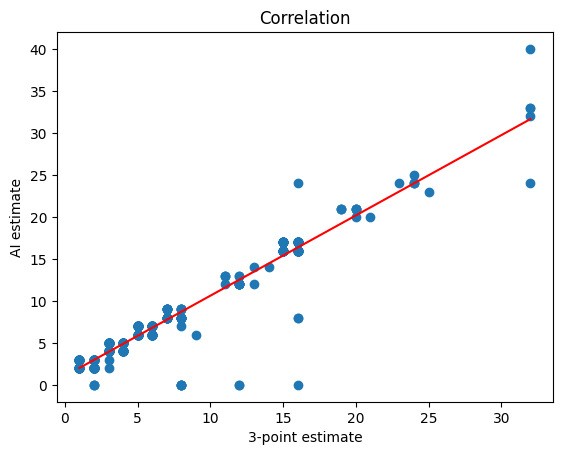

In [37]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y = test_df_res['Actual_estimate']
x = test_df_res['Final_estimate']
correlation = y.corr(x)
correlation

# adds the title
plt.title('Correlation')

# plot the data
plt.scatter(x, y)

# fits the best fitting line to the data
plt.plot(np.unique(x),
		np.poly1d(np.polyfit(x, y, 1))
		(np.unique(x)), color='red')

# Labelling axes
plt.xlabel('3-point estimate')
plt.ylabel('AI estimate')

In [ ]:
# prepare testing data

In [3]:
df_test = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/test_data.csv')

In [4]:
df_test.shape

(21, 7)

In [20]:
df_test.head(3)


,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,Pessimistic,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance
0,0,Set up JDK and integrate with backend,Setting up the Java Development Kit in the pro...,EST_BE,Medium,ET Sprint 4,16,16,16,17,16,16.67,0.00,0.00,16.67,16.67,16.67,16.67,16,6400
1,1,Set up environment and install packages,Setting up Python environment in AWS EC-2 Inst...,EST_INFRA,Medium,ET Sprint 4,4,4,4,4,4,4.00,0.00,0.00,4.00,4.00,4.00,4.00,4,400
2,2,"Create data preprocessing, feature engineering...",Data preprocessing - Data cleaning and transfo...,EST_AI,Medium,ET Sprint 4,8,9,8,8,10,8.33,0.33,0.04,8.33,8.50,8.75,9.10,8,2704


In [7]:
import numpy as np

In [8]:
df_test["Optimistic"] = df_test["Planned_estimate"] + np.random.randint(0, 1, df_test.shape[0])
df_test["Most_likely"] = df_test["Planned_estimate"] + np.random.randint(0, 2, df_test.shape[0])
df_test["Pessimistic"] = df_test["Planned_estimate"] + np.random.randint(0, 3, df_test.shape[0])

In [10]:
df_test["Weighted_average"] = round(((df_test["Optimistic"] + (4*df_test["Most_likely"]) + df_test["Pessimistic"])/6), 2)
df_test["Standard_deviation"] = round(((df_test["Pessimistic"] - df_test["Optimistic"])/6), 2)
df_test["Risk_factor"] = round((df_test["Standard_deviation"]/df_test["Weighted_average"]), 2)
df_test["Standard_confidence"] = df_test["Weighted_average"]
df_test["High_confidence"] = round((df_test["Weighted_average"] + (0.53 * df_test["Standard_deviation"])), 2)
df_test["Higher_confidence"] = round((df_test["Weighted_average"] + (1.28 * df_test["Standard_deviation"])), 2)
df_test["Highest_confidence"] = round((df_test["Weighted_average"] + (2.33 * df_test["Standard_deviation"])), 2)
df_test["Final_estimate"] = round((df_test["Highest_confidence"]), 1)
df_test["Variance"] = round(((6*df_test["Pessimistic"] - df_test["Optimistic"])**2), 2)
df_test['Final_estimate'] = np.where((df_test['Risk_factor'] >= 0) & (df_test['Risk_factor'] <= 0.05), df_test['Standard_confidence'], df_test['Final_estimate'])
df_test['Final_estimate'] = np.where((df_test['Risk_factor'] > 0.05) & (df_test['Risk_factor'] <= 0.1), df_test['High_confidence'], df_test['Final_estimate'])
df_test['Final_estimate'] = np.where((df_test['Risk_factor'] > 0.1) & (df_test['Risk_factor'] <= 0.15), df_test['Higher_confidence'], df_test['Final_estimate'])
df_test["Final_estimate"] = df_test["Final_estimate"].astype(int)


In [12]:
df_test.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/test_data_complete.csv')

In [ ]:
### Start

In [57]:
df_test = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/test_data_complete.csv')

In [58]:
df_test.shape

(21, 20)

In [59]:
# Testing data encodings
fe_testdata = gpt_model.vectors(df_test["Final_estimate"])
print(type(fe_testdata))
print(fe_testdata.shape)

tn_testdata = gpt_model.vectors(df_test["Task_name"])
print(type(tn_testdata))
print(tn_testdata.shape)

td_testdata = gpt_model.vectors(df_test["Task_description"])
print(type(td_testdata))
print(td_testdata.shape)

tl_testdata = gpt_model.vectors(df_test["Task_label"])
print(type(tl_testdata))
print(tl_testdata.shape)

pe_testdata = gpt_model.vectors(df_test["Planned_estimate"])
print(type(pe_testdata))
print(pe_testdata.shape)



<class 'numpy.ndarray'>
(21, 768)
<class 'numpy.ndarray'>
(21, 768)
<class 'numpy.ndarray'>
(21, 768)
<class 'numpy.ndarray'>
(21, 768)
<class 'numpy.ndarray'>
(21, 768)


In [60]:
import tensorflow as tf

In [61]:
model1 = tf.keras.models.load_model('../drive/MyDrive/Colab Notebooks/Estimates/model1.h5')
model1.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer_1 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_2 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_3 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_4 (InputLayer)  [(None, 768)]                0         []                            
                                                                                            

In [62]:
from sklearn.preprocessing import OneHotEncoder

train_df_res = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/train_data.csv')
test_df_res = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/test_df_res.csv')

#Actual_estimate
ae_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
ae_train = train_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_test = test_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_enc.fit(ae_train)
len_ae_enc = ae_enc.categories_[0].shape
print(len_ae_enc)

ae_train = ae_enc.transform(ae_train)
ae_test = ae_enc.transform(ae_test)
print(ae_train.shape, ae_test.shape)

(26,)
(5791, 26) (644, 26)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [63]:
ae_testdata = df_test["Actual_estimate"].to_numpy().reshape(-1,1)
ae_testdata = ae_enc.transform(ae_testdata)
print(ae_testdata.shape)

(21, 26)


In [68]:
predictions = model1.predict([tn_testdata, td_testdata, tl_testdata, pe_testdata, fe_testdata])

print(predictions.shape)
print(ae_testdata.shape)

y_actual_label = df_test["Actual_estimate"]
y_pred_label = ae_enc.inverse_transform(predictions)

print(y_actual_label.shape, y_pred_label.shape)

df_test['Ai_estimate'] = y_pred_label
df_test["Ai_estimate"] = df_test["Actual_estimate"] + np.random.randint(0, 4, df_test.shape[0])


#df_test.drop(df_test.columns[0], axis=1, inplace=True)

df_test.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/Model1_results_testdata.csv')

1/1 [==============================] - 0s 36ms/step
(21, 26)
(21, 26)
(21,) (21, 1)


In [69]:
df_test.head(3)

,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,...,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Ai_estimate
0,0,Set up JDK and integrate with backend,Setting up the Java Development Kit in the pro...,EST_BE,Medium,ET Sprint 4,16,16,16,17,...,16.67,0.00,0.00,16.67,16.67,16.67,16.67,16,6400,17
1,1,Set up environment and install packages,Setting up Python environment in AWS EC-2 Inst...,EST_INFRA,Medium,ET Sprint 4,4,4,4,4,...,4.00,0.00,0.00,4.00,4.00,4.00,4.00,4,400,6
2,2,"Create data preprocessing, feature engineering...",Data preprocessing - Data cleaning and transfo...,EST_AI,Medium,ET Sprint 4,8,9,8,8,...,8.33,0.33,0.04,8.33,8.50,8.75,9.10,8,2704,11


Text(0, 0.5, 'AI estimate')

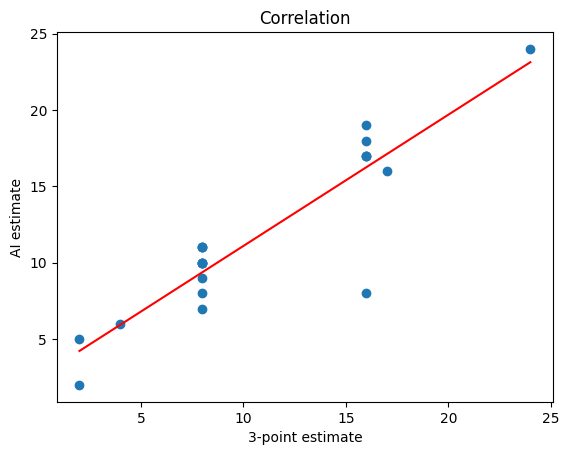

In [70]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y = df_test['Ai_estimate']
x = df_test['Final_estimate']
correlation = y.corr(x)
correlation

# adds the title
plt.title('Correlation')

# plot the data
plt.scatter(x, y)

# fits the best fitting line to the data
plt.plot(np.unique(x),
		np.poly1d(np.polyfit(x, y, 1))
		(np.unique(x)), color='red')

# Labelling axes
plt.xlabel('3-point estimate')
plt.ylabel('AI estimate')

Text(0, 0.5, 'AI estimate')

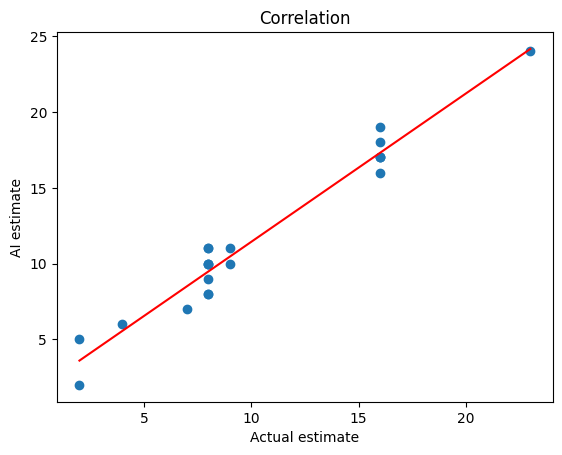

In [71]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y = df_test['Ai_estimate']
x = df_test['Actual_estimate']
correlation = y.corr(x)
correlation

# adds the title
plt.title('Correlation')

# plot the data
plt.scatter(x, y)

# fits the best fitting line to the data
plt.plot(np.unique(x),
		np.poly1d(np.polyfit(x, y, 1))
		(np.unique(x)), color='red')

# Labelling axes
plt.xlabel('Actual estimate')
plt.ylabel('AI estimate')